In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pprint import pprint
from datetime import datetime
from zoneinfo import ZoneInfo
from scipy.integrate import cumulative_trapezoid
from scipy.signal import butter, filtfilt, detrend

In [2]:
POSITIONS = ['sit', 'stand', 'standtandem', 'standsingle', 'sts']
VARIATIONS = ['', 'eyesclosed', 'foam', 'foameyesclosed']

V_AXES = ['vx','vy','vz']
A_AXES = ['ax','ay','az']

lp_cutoff = 10
bp_cutoff = (0.1, 10)

BASE_PATH = "/Users/edwardzhou/Desktop/FRL/BalanceProject/data/6-10"

def lowpass(signal, time, cutoff, order=4):
    dt = np.median(np.diff(time))
    fs = 1 / dt
    b, a = butter(order, cutoff / (0.5 * fs), btype='lowpass')
    # return signal
    return filtfilt(b, a, signal)

def bandpass(signal, time, cutoff, order=4):
    dt = np.median(np.diff(time))
    fs = 1 / dt
    b, a = butter(order, cutoff / (0.5 * fs), btype='bandpass')
    # return signal
    return filtfilt(b, a, signal)

def load_opti(test_name):
    filename = f"{BASE_PATH}/optitrack/{test_name}.csv"
    
    with open(filename, 'r') as f:
        metadata = next(f)
        meta = metadata.split(',')
        meta_dict = {meta[i]: meta[i+1] for i in range(0, len(meta), 2)}
        df = pd.read_csv(f, skiprows=4, header=[0, 1])

    start_time = datetime.strptime(
        meta_dict['Capture Start Time'],
        "%Y-%m-%d %I.%M.%S.%f %p"
    )
    start_time = start_time.replace(tzinfo=ZoneInfo("America/New_York"))

    df = df.iloc[:, :8]
    df.columns = ["_".join([i.lower() for i in col if "Unnamed" not in i]) for col in df.columns]

    df['timestamp'] = (df['time (seconds)'] + start_time.timestamp()) * 1000
    return df

def load_app(test_name):
    filename = f"{BASE_PATH}/airpods/{test_name}.csv"
    df = pd.read_csv(filename)
    df = df[df["source"] == "airpods"].iloc[1:]
    return df

def load_app_json(test_name):
    filename = f"{BASE_PATH}/airpods/{test_name}.json"
    with open(filename, "r") as f:
        data = json.load(f)
        
    df = pd.json_normalize(data["airpodsDatapoints"])
    return df.rename(columns={'timing.timestampEpoch': 'timestampEpoch', 'accelerationX': 'accel_x', 'accelerationY': 'accel_y', 'accelerationZ': 'accel_z'})

# ---------------------- PROCESS ----------------------
def process_trial(opti, app):
    
    df_opti = load_opti(opti)
    df_app = load_app_json(app)

    # Align time
    t_opti = df_opti["timestamp"].values / 1000
    t_app = df_app["timestampEpoch"].values / 1000

    t_start = max(t_opti[0], t_app[0]) + 3
    t_end = min(t_opti[-1], t_app[-1]) - 3

    mask_o = (t_opti >= t_start) & (t_opti <= t_end)
    mask_a = (t_app >= t_start) & (t_app <= t_end)

    t_opti = t_opti[mask_o]
    t_app = t_app[mask_a]

    t_opti -= t_start
    t_app -= t_start

    df_opti = df_opti[mask_o]
    df_app = df_app[mask_a]

    px_opti = df_opti["position_x"].values / 1000
    py_opti = df_opti["position_y"].values / 1000
    pz_opti = df_opti["position_z"].values / 1000

    px_opti_f = lowpass(px_opti, t_opti, lp_cutoff)
    py_opti_f = lowpass(py_opti, t_opti, lp_cutoff)
    pz_opti_f = lowpass(pz_opti, t_opti, lp_cutoff)

    vx_opti = np.gradient(px_opti_f, t_opti)
    vy_opti = np.gradient(py_opti_f, t_opti)
    vz_opti = np.gradient(pz_opti_f, t_opti)
    
    ax_opti = np.gradient(vx_opti, t_opti)
    ay_opti = np.gradient(vy_opti, t_opti)
    az_opti = np.gradient(vz_opti, t_opti)

    ax_app = df_app["accel_x"].values * -9.81
    ay_app = df_app["accel_y"].values * -9.81
    az_app = df_app["accel_z"].values * -9.81

    ax_app = bandpass(detrend(ax_app), t_app, bp_cutoff)
    ay_app = bandpass(detrend(ay_app), t_app, bp_cutoff)
    az_app = bandpass(detrend(az_app), t_app, bp_cutoff)

    vx_app = cumulative_trapezoid(ax_app, t_app, initial=0)
    vy_app = cumulative_trapezoid(ay_app, t_app, initial=0)
    vz_app = cumulative_trapezoid(az_app, t_app, initial=0)

    return {
        "opti": {
            "time": t_opti,
            "vx": vx_opti * -1,
            "vy": vz_opti * -1,
            "vz": vy_opti * -1,
            "ax": ax_opti,
            "ay": ay_opti,
            "az": az_opti,
        },
        "app": {
            "time": t_app,
            "vx": vx_app,
            "vy": vy_app,
            "vz": vz_app,
            "ax": ax_app,
            "ay": ay_app,
            "az": az_app,
        },
        "label": opti
    }

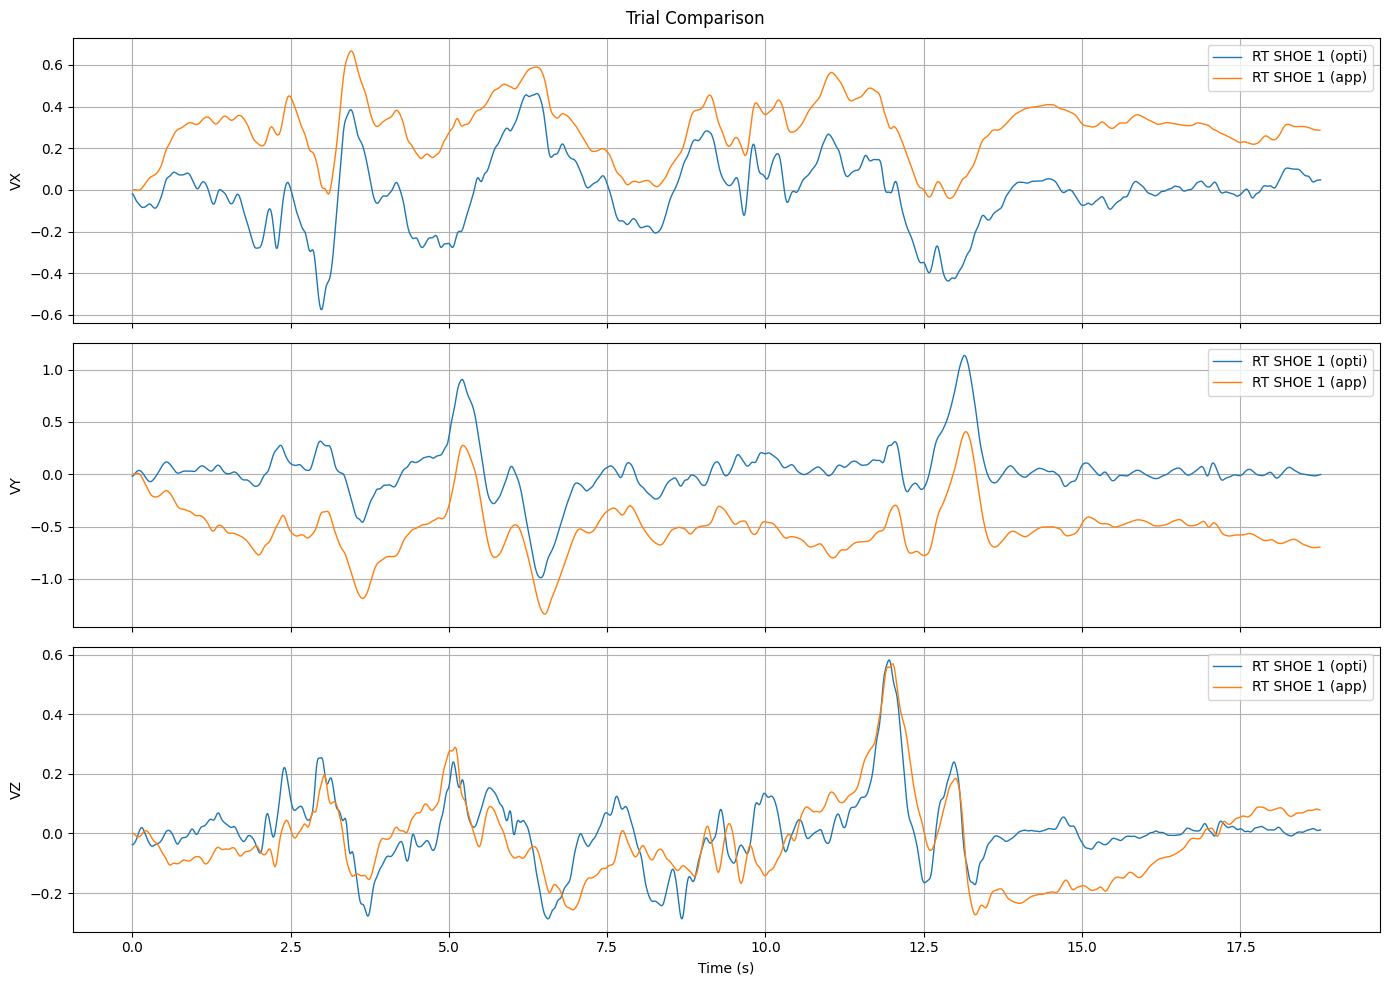

In [104]:
trial_1_opti = "RT SHOE 1"
trial_1_app = "RT SHOE 1"

trial_2_opti = "STS 1" 
trial_2_app = "STS 1"

plot_data = V_AXES
plot_source = "opti"


trial1 = process_trial(trial_1_opti, trial_1_app)
trial2 = process_trial(trial_2_opti, trial_2_app)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)


for i, axis in enumerate(plot_data):
    axes[i].plot(trial1["opti"]["time"], trial1["opti"][axis],
                 label=f'{trial1["label"]} ({"opti"})', linewidth=1)
    # axes[i].plot(trial2["opti"]["time"], trial2["opti"][axis],
    #              label=f'{trial2["label"]} ({"opti"})', linewidth=1)

    axes[i].plot(trial1["app"]["time"], trial1["app"][axis],
                 label=f'{trial1["label"]} ({"app"})', linewidth=1)
    # axes[i].plot(trial2["app"]["time"], trial2["app"][axis],
    #              label=f'{trial2["label"]} ({"app"})', linewidth=1)

    axes[i].set_ylabel(axis.upper())
    axes[i].grid(True)
    axes[i].legend()

axes[-1].set_xlabel("Time (s)")
plt.suptitle("Trial Comparison")
plt.tight_layout()
plt.savefig("my_plot.png", dpi=300, bbox_inches="tight")
plt.show()